#  Linear regression

In this part, you will implement linear regression with multiple variables to
predict the prices of houses. Suppose you are selling your house and you
want to know what a good market price would be. One way to do this is to
first collect information on recent houses sold and make a model of housing
prices

The fille ex1data2.txt contains a training set of housing prices in Portland, Oregon. The first column is the size of the house (in square feet), the
second column is the number of bedrooms, and the third column is the price
of the house.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('ex1data2.txt', delimiter=',')  # Load the text file with a comma as a delimiter
print(data[0:5,:])

[[2.104e+03 3.000e+00 3.999e+05]
 [1.600e+03 3.000e+00 3.299e+05]
 [2.400e+03 3.000e+00 3.690e+05]
 [1.416e+03 2.000e+00 2.320e+05]
 [3.000e+03 4.000e+00 5.399e+05]]


In [13]:
#load the data a create a np vectors X and y
X = data[:, 0:2]  # Select all rows and first two columns
m = X.shape[0]
y = data[:, 2].reshape(-1, 1)   # Select all rows and the last column
del data
print('First 10 examples from the dataset:')
for i in range(10):
     print(f'x = [{X[i, 0]:.0f} {X[i, 1]:.0f}], y = {y[i,0].item():.0f}')


First 10 examples from the dataset:
x = [2104 3], y = 399900
x = [1600 3], y = 329900
x = [2400 3], y = 369000
x = [1416 2], y = 232000
x = [3000 4], y = 539900
x = [1985 4], y = 299900
x = [1534 3], y = 314900
x = [1427 3], y = 198999
x = [1380 3], y = 212000
x = [1494 3], y = 242500


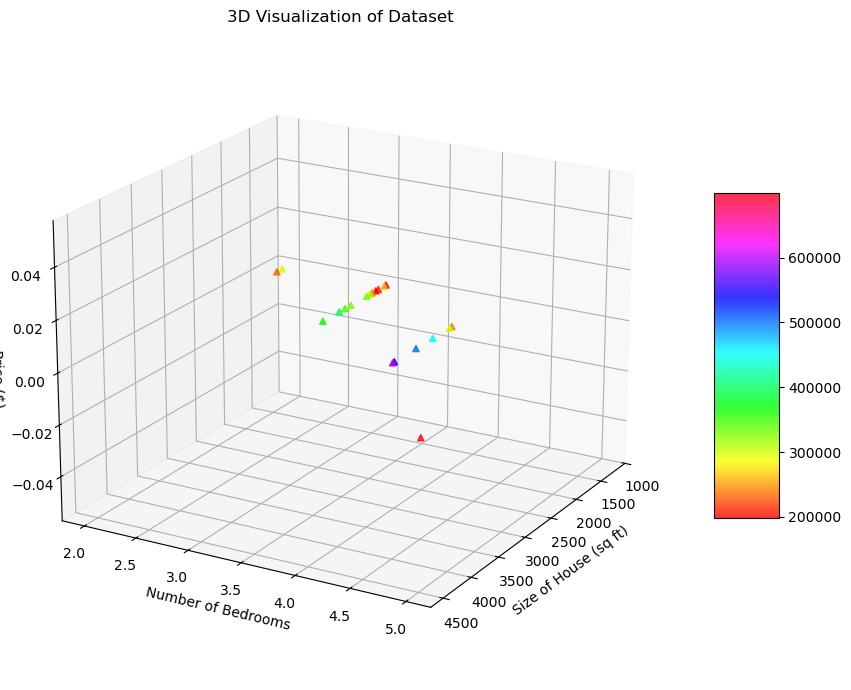

In [14]:
# ==================== Part 1: Plotting ====================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# Plot the points with red x markers
my_cmap = plt.get_cmap('hsv')
sctt = ax.scatter3D(X[0:20, 0], X[0:20, 1],
                    alpha = 0.8,
                    c = y[0:20,0],
                    cmap = my_cmap,
                    marker ='^')
# Label axes
ax.set_xlabel('Size of House (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('Price ($)')
fig.colorbar(sctt, ax = ax, shrink = 0.5, aspect = 5)
# Set grid and view angle similar to MATLAB
ax.view_init(elev=20, azim=30)
ax.grid(True)
plt.title('3D Visualization of Dataset')
plt.tight_layout()
plt.show()

# Feature normalization

Your task here is to complete the code in featureNormalize.m to

*   Subtract the mean value of each feature from the dataset.
*   After subtracting the mean, additionally scale (divide) the feature values
by their respective standard deviations

The mean and std should be:

mu= [2000.68085106    3.17021277], std = [7.94702354e+02 7.60981887e-01]

In [15]:
def featureNormalize(X):
     mu = np.mean(X, axis=0)  # Compute the mean of each feature
     sigma = np.std(X, axis=0)  # Compute the standard deviation of each feature
     X_norm = (X - mu) / sigma  # Normalize the features
     return X_norm, mu, sigma  # Return the normalized features, mean, and standard deviation

[X_norm,mu, sigma] = featureNormalize(X)
print(f'mu= {mu}, std = {sigma}')
print('First 10 examples from the dataset:')
for i in range(10):
     print(f'x = [{X_norm[i, 0]:.4f} {X_norm[i, 1]:.4f}]')
print(X_norm.shape)

mu= [2000.68085106    3.17021277], std = [7.86202619e+02 7.52842809e-01]
First 10 examples from the dataset:
x = [0.1314 -0.2261]
x = [-0.5096 -0.2261]
x = [0.5079 -0.2261]
x = [-0.7437 -1.5544]
x = [1.2711 1.1022]
x = [-0.0199 1.1022]
x = [-0.5936 -0.2261]
x = [-0.7297 -0.2261]
x = [-0.7895 -0.2261]
x = [-0.6445 -0.2261]
(47, 2)


# Cost Function

The objective of linear regression is to minimize the cost function:
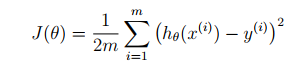

where the hypothesis h is given by

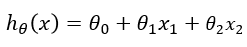




In [16]:
def hypothesis(theta, X):
    return X @ theta
def cost_function(theta, X, y):
    m = len(y)
    h = hypothesis(theta, X)
    error = y-h
    J = (1 / (2 * m)) * error.T @ error
    return J.item()
X_ = np.hstack([np.ones((m, 1)), X_norm])
del X_norm
print(X_[0:5,:])
theta_0 = np.zeros((3, 1))
print(f"Model parameters: {theta_0}")
print(f"Cost function: {cost_function(theta_0, X_, y)}")


[[ 1.          0.13141542 -0.22609337]
 [ 1.         -0.5096407  -0.22609337]
 [ 1.          0.5079087  -0.22609337]
 [ 1.         -0.74367706 -1.5543919 ]
 [ 1.          1.27107075  1.10220517]]
Model parameters: [[0.]
 [0.]
 [0.]]
Cost function: 65591548106.45744


# Gradient descent

Next, you will implement gradient descent in the file gradientDescent.m.
The loop structure has been written for you, and you only need to supply
the updates to θ within each iteration.

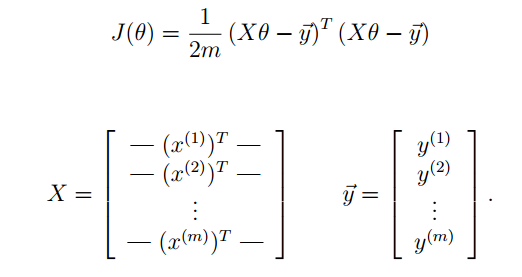

Using the following values:
iterations = 3
theta = np.zeros((2, 1))
alpha = 0.01

The first three iteration:

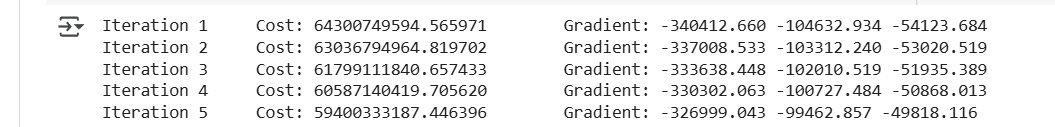

In [17]:
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)  
    J_history = np.zeros(iterations)
    theta_history = np.zeros((iterations, theta.shape[0]))
    for iter in range(iterations):
        gradients = 1/m * X.T @ (X @ theta - y)
        theta_history[iter] = theta.flatten()
        theta = theta - alpha * gradients
        J_history[iter] = cost_function(theta, X, y)
        if iter % 50 == 0:
            print(f"Iteration {iter + 1}\tCost: {J_history[iter]:.6f}\tGradient: {gradients.ravel()}")
    
    if iterations < 10:
        return theta
    else:
        return theta, J_history, theta_history

In [18]:
alpha = 0.01
theta= gradientDescent(X_, y, theta_0, alpha, 3);
input_features = np.array([2000, 3])
normalized_features = (input_features - mu) / sigma
print(normalized_features)
print(f"theta: {theta}")    
# Add the bias term (1) as the first element
predict1 = np.hstack([1, normalized_features]) @ theta
print(f'For a house with {input_features[0]} sqft and {input_features[1]} bedrooms, we predict a profit of ${(predict1 * 10000).item():.2f}')

Iteration 1	Cost: 64297776251.620110	Gradient: [-340412.65957447 -105764.13349282  -54708.82175587]
[-0.000866   -0.22609337]
theta: [[10110.59640202]
 [ 3132.20441912]
 [ 1607.2749847 ]]
For a house with 2000 sqft and 3 bedrooms, we predict a profit of $97444897.01


# Visualization

#Selecting learning rates

In this part of the exercise, you will get to try out different learning rates for
the dataset and find a learning rate that converges quickly. You can change
the learning rate and call the function "gradientDescent".

You need to modify "gradientDescent" function and it should also return the history of J(θ) values in a vector J. After the last iteration, the ex1 multi.m script plots the J values against
the number of the iterations.

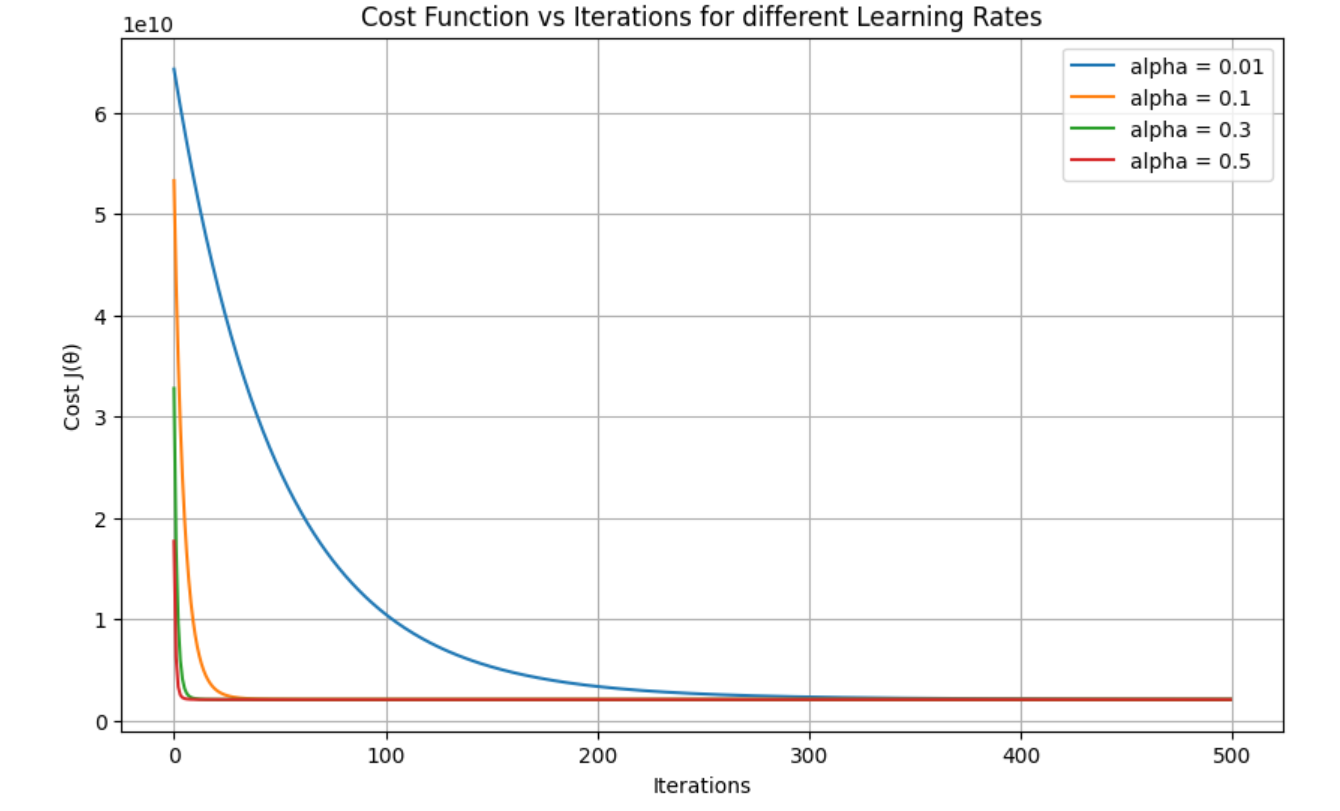

In [19]:
iterations = 500
alpha_vector = np.array([0.01, 0.1, 0.3, 0.5])
matrix_J = np.zeros((iterations, len(alpha_vector)))

In [ ]:
for i in range(len(alpha_vector)):
    theta = np.zeros((3, 1))
    alpha = alpha_vector[i]
    print(f"For alpha = {alpha:.2f}\n")
    theta, j,th = gradientDescent(X_, y, theta, alpha, iterations)
    matrix_J[:, i] = j.ravel()
    print(f"Alpha: {alpha:.2f}, Theta found by gradient descent: {theta.ravel()}")


Iteration 1	Cost: 64297776251.620110	Gradient: [-340412.65957447 -105764.13349282  -54708.82175587]
Iteration 51	Cost: 24603881257.415604	Gradient: [-205951.72437298  -57032.20083187  -16079.91232402]
Iteration 101	Cost: 10431601126.161716	Gradient: [-124602.04278309  -33079.32933526    -230.83861071]
Iteration 151	Cost: 5254909597.623323	Gradient: [-75384.9918615  -20762.27408511   5586.02981184]
Iteration 201	Cost: 3321607823.085979	Gradient: [-45608.37744732 -14024.3780928    7110.02117285]
Iteration 251	Cost: 2579779044.395034	Gradient: [-27593.34506793 -10051.22533991   6901.01697771]
Iteration 301	Cost: 2284298697.532002	Gradient: [-16694.14117872  -7516.45710376   6081.20971342]


Iteration 351	Cost: 2160329755.276730	Gradient: [-10100.05669877  -5780.40606189   5126.50167378]
Iteration 401	Cost: 2104694472.893401	Gradient: [-6110.59558119 -4523.2639648   4225.34253908]
Iteration 451	Cost: 2077712344.636668	Gradient: [-3696.94740044 -3576.56623803  3440.83205805]
For alpha = 0.01

Alpha: 0.01, Theta found by gradient descent: [ 3.38175984e+05  1.03032124e+05 -2.02325233e+02]
Iteration 1	Cost: 53268259941.691582	Gradient: [-340412.65957447 -105764.13349282  -54708.82175587]
Iteration 51	Cost: 2059561279.948449	Gradient: [-1754.41032517 -2707.1442911   2673.83168884]
Iteration 101	Cost: 2043447088.960844	Gradient: [  -9.04183644 -283.56751313  283.56059777]
Iteration 151	Cost: 2043281905.716667	Gradient: [ -0.04659959 -29.88624211  29.88624068]
Iteration 201	Cost: 2043280071.209630	Gradient: [-2.40163811e-04 -3.14986123e+00  3.14986123e+00]
Iteration 251	Cost: 2043280050.831731	Gradient: [-1.23773597e-06 -3.31979711e-01  3.31979711e-01]
Iteration 301	Cost: 2043280

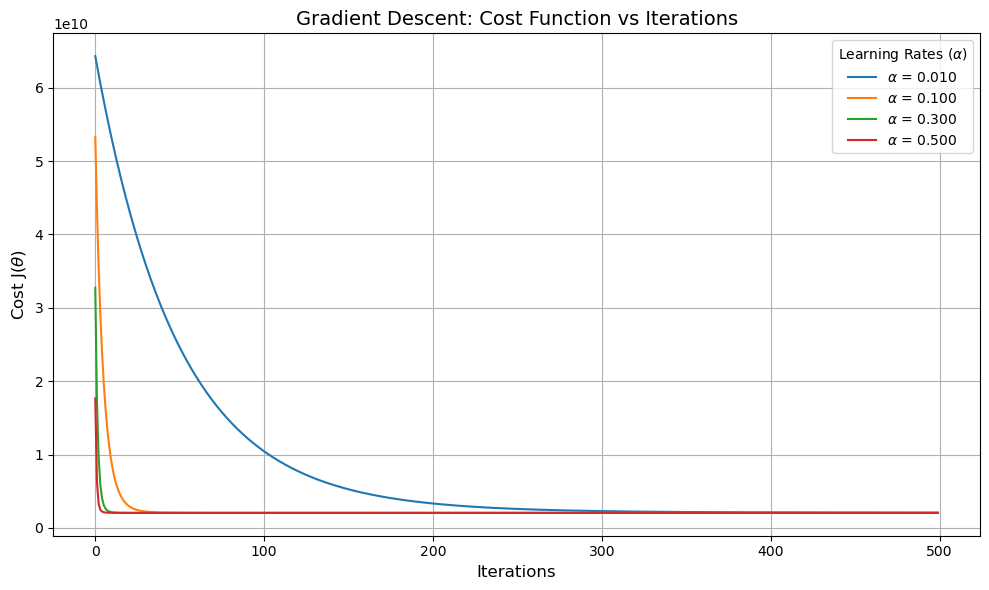

In [24]:
plt.figure(figsize=(10, 6))
for i, alpha in enumerate(alpha_vector):
    plt.plot(range(iterations), matrix_J[:, i], label=fr'$\alpha$ = {alpha:.3f}')

plt.xlabel("Iterations", fontsize=12)
plt.ylabel(r"Cost J$(\theta)$", fontsize=12)
plt.title("Gradient Descent: Cost Function vs Iterations", fontsize=14)
plt.legend(title=r"Learning Rates ($\alpha$)")
plt.grid(True)
plt.tight_layout()
plt.show()


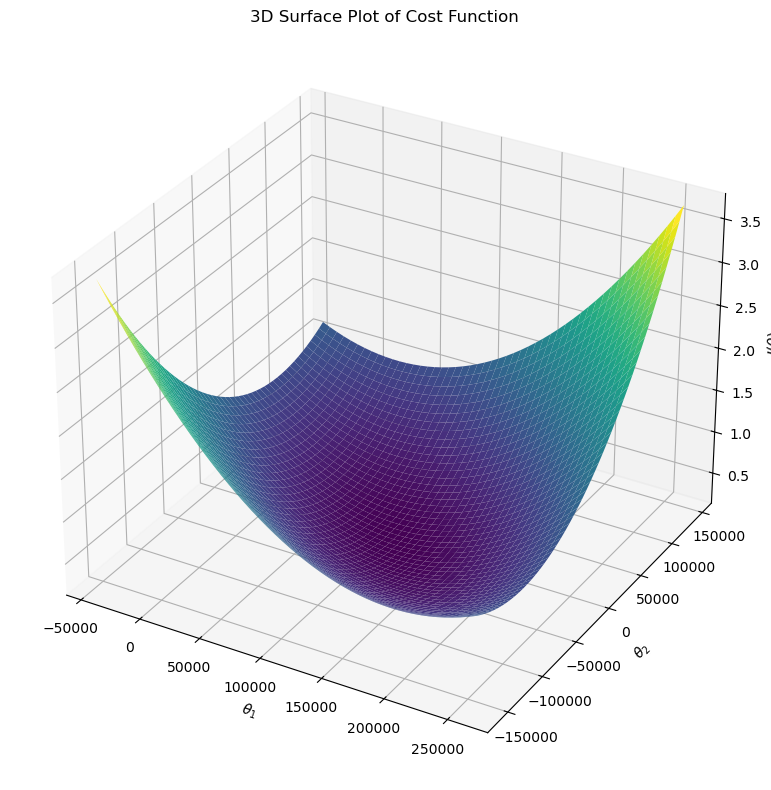

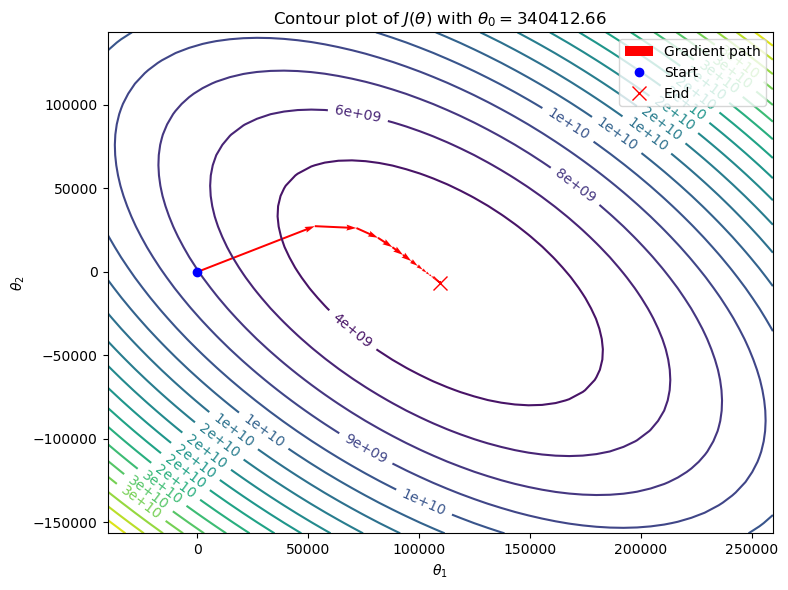

In [25]:
from mpl_toolkits.mplot3d import Axes3D

theta0_fixed = theta[0, 0]
theta1_center = theta[1, 0]
theta2_center = theta[2, 0]
delta1 = 150000  
delta2 = 150000   
theta1_vals = np.linspace(theta1_center - delta1, theta1_center + delta1, 50)
theta2_vals = np.linspace(theta2_center - delta2, theta2_center + delta2, 50)
J_vals = np.zeros((len(theta1_vals), len(theta2_vals)))

for i in range(len(theta1_vals)):
    for j in range(len(theta2_vals)):
        t = np.array([[theta0_fixed], [theta1_vals[i]], [theta2_vals[j]]])
        J_vals[i, j] = cost_function(t, X_, y)

J_vals = J_vals.T  

theta1_mesh, theta2_mesh = np.meshgrid(theta1_vals, theta2_vals)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta1_mesh, theta2_mesh, J_vals, cmap='viridis')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel(r'$J(\theta)$')
ax.set_title('3D Surface Plot of Cost Function')
plt.tight_layout()
plt.show()
theta_init = np.zeros((2, 1))

plt.figure(figsize=(8, 6))
levels = np.linspace(J_vals.min(), J_vals.max(), 20)
cp = plt.contour(theta1_vals, theta2_vals, J_vals, levels=levels, cmap='viridis')
plt.clabel(cp, fmt="%.0e")
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(r'Contour plot of $J(\theta)$ with $\theta_0 = {:.2f}$'.format(theta0_fixed))
theta1_path = th[:, 1]
theta2_path = th[:, 2]
u = theta1_path[1:] - theta1_path[:-1]
v = theta2_path[1:] - theta2_path[:-1]
plt.quiver(theta1_path[:-1], theta2_path[:-1], u, v, 
           angles='xy', scale_units='xy', scale=1, color='red', width=0.003, label='Gradient path')
# Punto inicial y final
plt.plot(theta1_path[0], theta2_path[0], 'bo', label='Start')
plt.plot(theta1_center, theta2_center, 'rx', markersize=10, linewidth=2, label='End')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
